# Project Setup

## Project Details (Add Project Name)


**Dataset:** Home Credit Default Risk - Kaggle Comp
**Author:** Chuch  
**Date:** 20/06/2026  
**Objective:** Build out a full PD Model Project  
**Status:** In Progress - Currently in EAD 

## Environment and Imports

In [1]:
# ══════════════════════════════════════════════════════
# Environment Setup
# ══════════════════════════════════════════════════════

# ── Standard Library ──────────────────────────────────
import os
import sys
import warnings

# ── Data ──────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ── Machine Learning ──────────────────────────────────
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Jupyter ───────────────────────────────────────────
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display

def find_repo_root(start, repo_name='CreditRiskLearning'):
    path = os.path.abspath(start)
    while True:
        if os.path.basename(path) == repo_name:
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(f"Could not find repo root: {repo_name}")
        path = parent

repo_root = find_repo_root(os.getcwd())
sys.path.append(os.path.join(repo_root, 'Core Resources'))
sys.path.append(os.path.join(repo_root, 'Core Resources', 'Scripts'))

import python_style_util as psu
import evaluation_utils as eu
import missingness_viz as mv        # missingess assessment functions

# ══════════════════════════════════════════════════════
# Display Settings
# ══════════════════════════════════════════════════════

%matplotlib inline

# Pandas
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'left')



# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Style Guide

c:\Users\User\Desktop\CreditRiskLearning\Core Resources\python_style_util.py:888: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle(


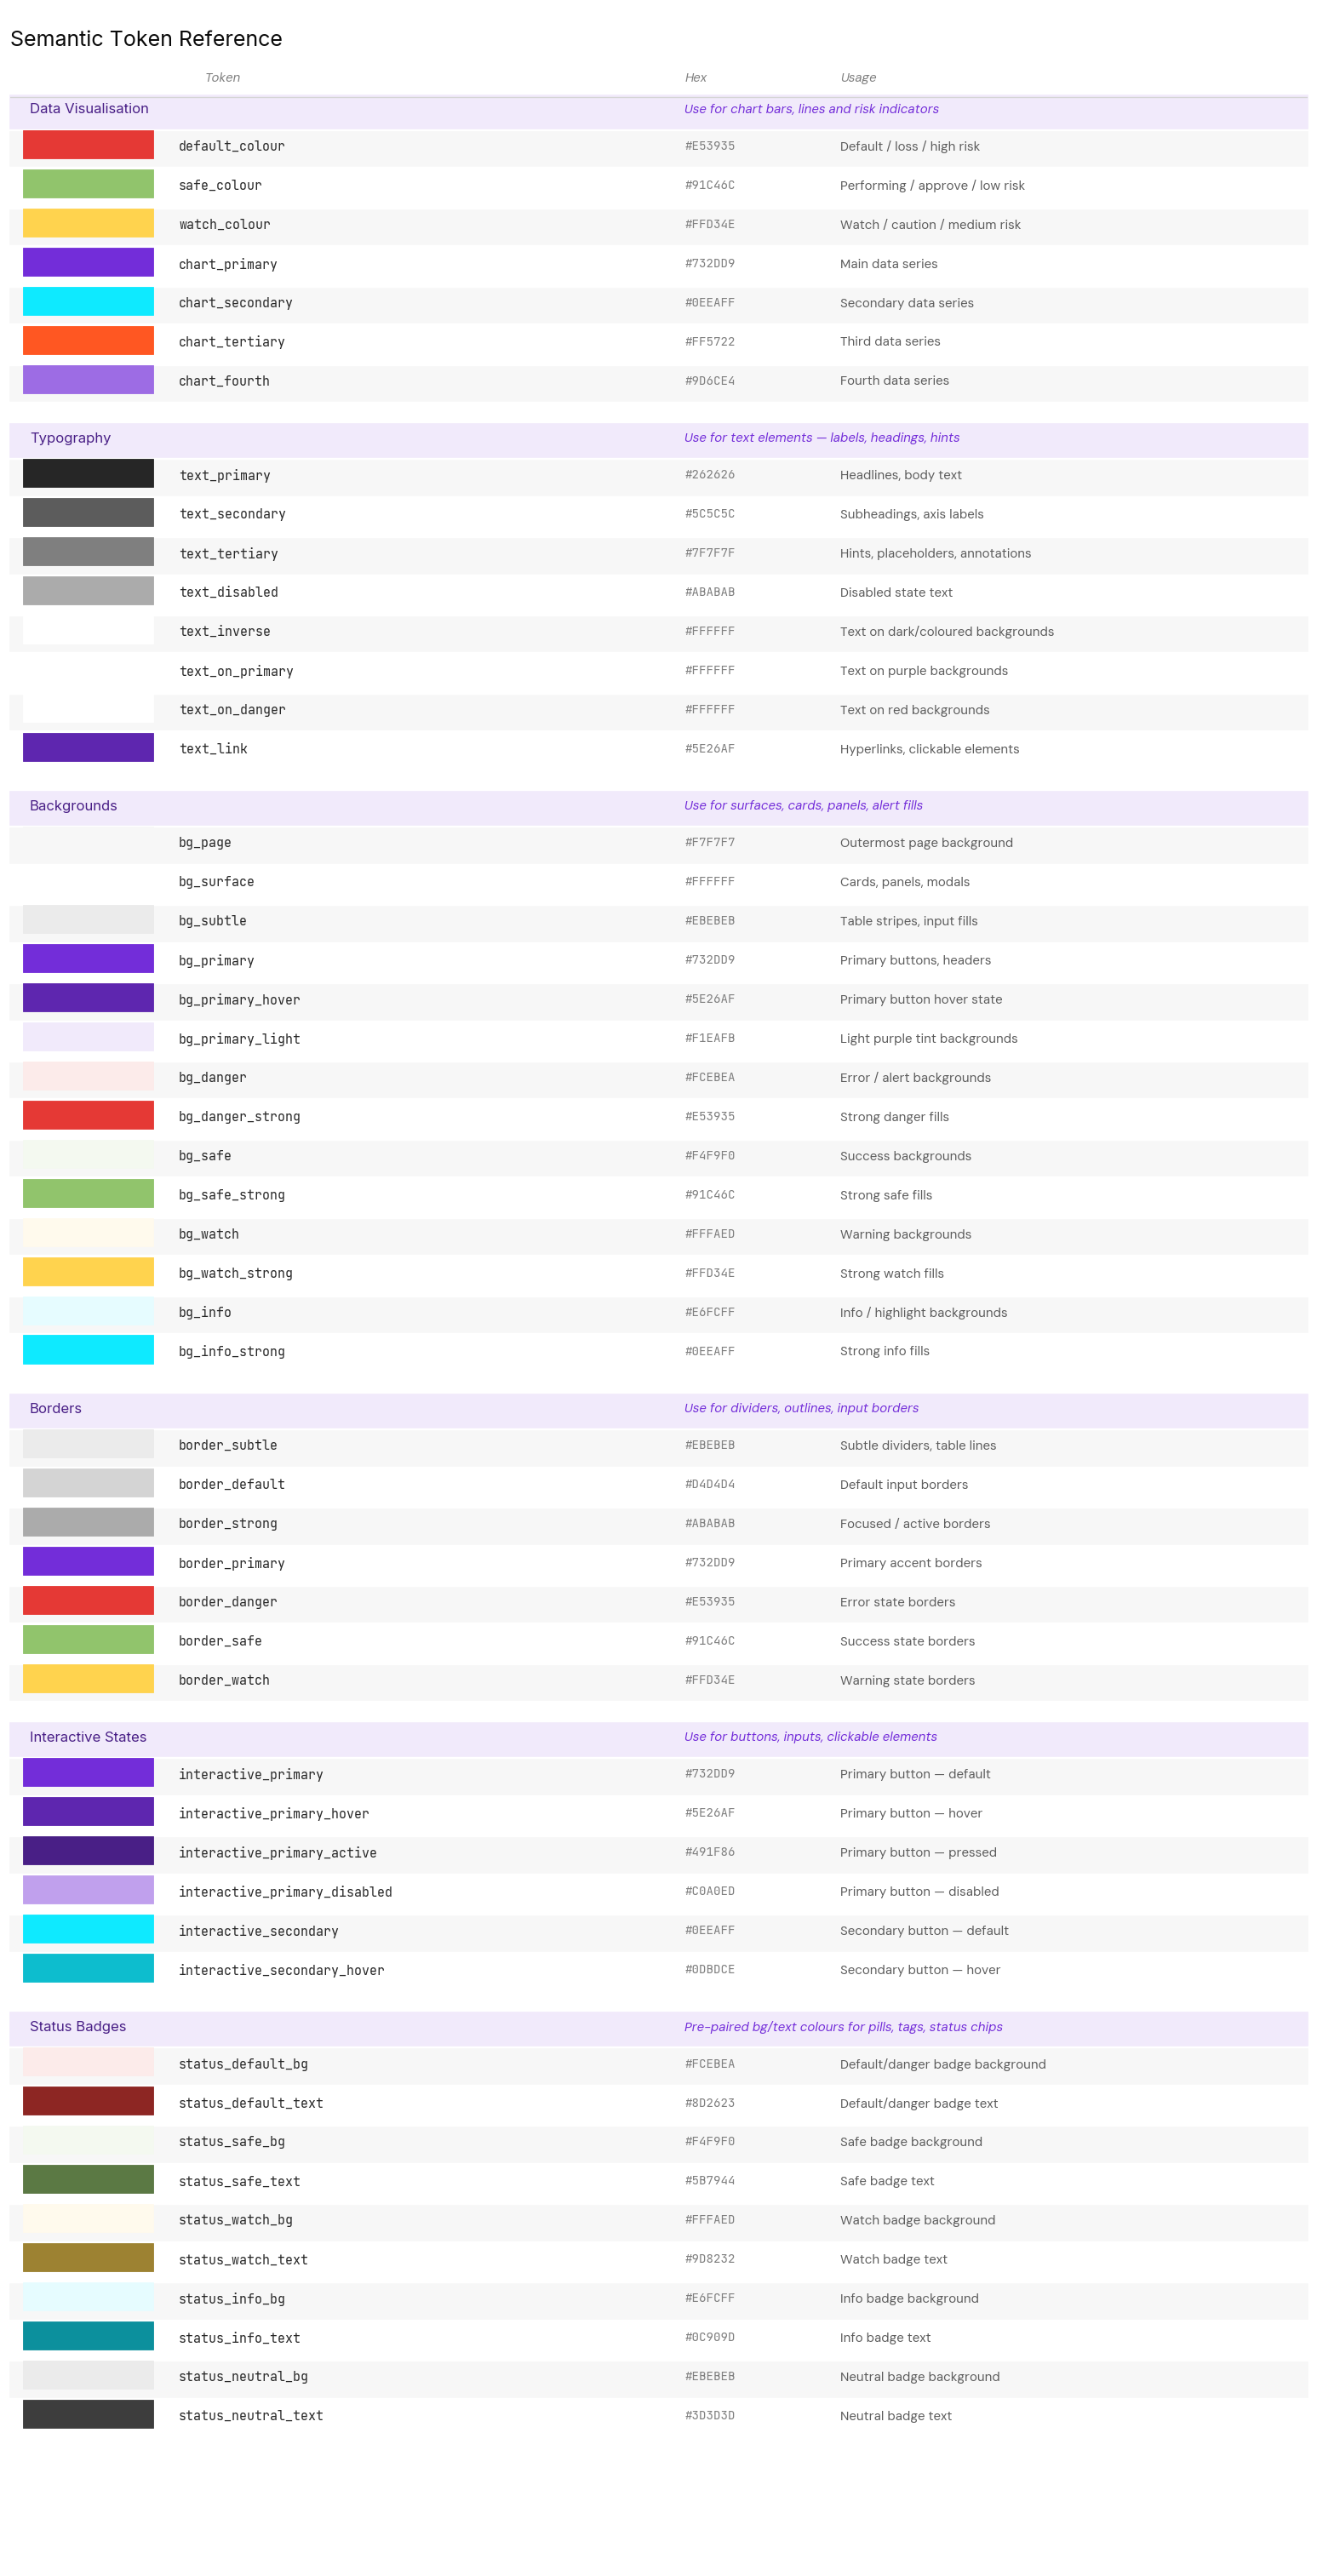

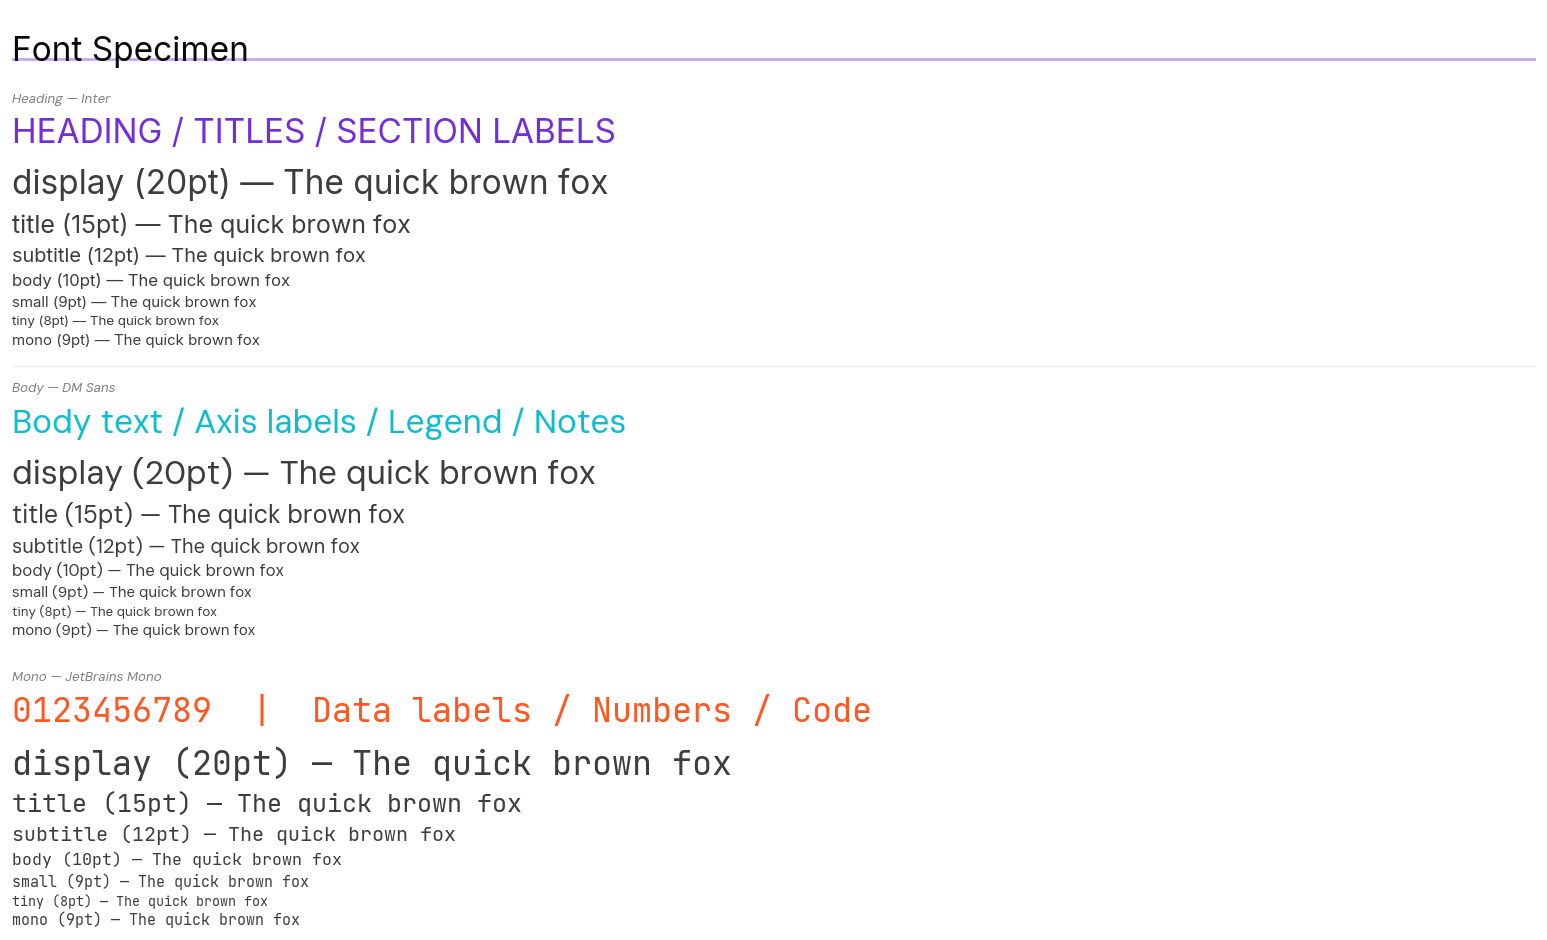

In [2]:
psu.show_tokens()
psu.show_fonts()


In [3]:
import os

core = os.path.join(os.path.abspath('..'), 'Core Resources')
scripts = os.path.join(os.path.abspath('..'), 'Core Resources', 'Scripts')

print("Core Resources contents:")
print(os.listdir(core))

print("\nScripts contents:")
print(os.listdir(scripts) if os.path.exists(scripts) else "Scripts folder doesn't exist")

Core Resources contents:
['lgbm_model_20260616_1929.joblib', 'logreg_model_20260616_1929.joblib', 'notebook_template.ipynb', 'preprocessor_20260616_1929.joblib', 'python_style_util.py', 'Scripts', '__pycache__']

Scripts contents:
['evaluation_utils.py', 'missingness_viz.py', '__pycache__']


## Display Setttings

In [4]:
# --- Pandas ---

pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places on floats
pd.set_option('display.max_columns', None)              # show all columns
pd.set_option('display.max_rows', None)                  # show up to 100 rows
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)                    # don't wrap wide dataframes
pd.set_option('display.colheader_justify', 'left')      # left-align column headers
pd.set_option('display.precision', 4)                   # decimal precision for describe()
pd.set_option('display.large_repr', 'truncate')         # truncate instead of summary for large dfs

# --- NumPy ---

np.set_printoptions(
    precision=4,        # decimal places (you have this)
    suppress=True,      # no scientific notation (you have this)
    linewidth=120,      # wrap width (you have this)
    threshold=1000,     # show up to 1000 elements before summarising with ...
    edgeitems=5,        # show 5 items at each end when it does summarise
)

# --- Matplotlib ---

%matplotlib inline
plt.rcParams['figure.dpi'] = 120             # sharper figures
plt.rcParams['savefig.dpi'] = 150            # higher res when saving
plt.rcParams['savefig.bbox'] = 'tight'       # no clipped labels when saving
plt.rcParams['savefig.facecolor'] = 'white'  # white background on saved figures

# --- Jupyter ---

InteractiveShell.ast_node_interactivity = 'all'  # print every expression, not just the last

# --- Warnings ---

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# --- Style ---

psu.set_style()

## Data Loading

In [5]:
# Build path relative to notebook location
base_path = os.path.dirname(os.path.abspath('this_notebook.ipynb'))
data_path = os.path.join(base_path, 'German Credit Data', 'german.data')

# Load data
df = pd.read_csv('../Home Credit Default Risk/application_train.csv', sep=',')

# Loan Description File
desc = pd.read_csv('../Home Credit Default Risk/HomeCredit_columns_description.csv', sep=',', encoding='cp1252')

# Project Body

## 1. Exploratory Data Analysis


### 1.1 Structural Skeleton

Before any feature-level analysis begins, two columns need to be separated from the working feature set: SK_ID_CURR, the unique row identifier, and TARGET, the label being predicted. Neither is a feature — SK_ID_CURR carries no predictive information about default risk, and TARGET is the outcome being modelled, not an input to it. Both are extracted into their own variables (df_id, df_target) so every dtype summary, missingness check, distribution plot, and correlation matrix from this point forward operates purely on the candidate feature set in df. df_target is reintroduced explicitly wherever it's needed — class balance checks, bivariate default-rate analysis, and ultimately as y when the model is fit — and df_id is kept aside to re-attach predictions to the original applicant ID at scoring time.

#### Isolation and Shape

Isolate SK_ID_CURR and Target. Separate them from the training data.

In [6]:
df_id = df['SK_ID_CURR']

df_target = df['TARGET']

df = df.drop(columns = ['SK_ID_CURR', 'TARGET'])

In [7]:
# Look at the shape of the dataset - understand breadth and depth

df.shape

(307511, 120)

**Observation:** Once SK_ID_CURR and TARGET are removed, the feature set should sit at 307,511 rows and 120 columns.

**Decision:** With roughly 2,500 rows for every column (307,511 rows against 120), the row-to-feature ratio is comfortably large enough that overfitting from dimensionality alone is not a meaningful risk at this stage. No columns will be dropped on parameter-count grounds, and the full feature set proceeds into EDA. This doesn't rule out removing or engineering features later — for reasons like multicollinearity, near-zero variance, or leakage — but those will be addressed if and when they're identified, not pre-emptively here.

In [8]:
# Overview of the data through a scrollable table

# Using this to get an understanding of what the entries in each column look like 

df.head(10)

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
3,Cash loans,F,N,Y,0,135000.

**Observation:** A quick scan of the first ten rows confirms a mix of numeric, categorical, and flag-style columns, with a loose grouping visible by column-name prefix (FLAG_*, NAME_*, AMT_*, DAYS_*) — an early hint that columns cluster by domain and naming convention, which the rest of this EDA leans on directly through the domain-bucket structure.

#### Description Lookup For Reference 

With 122 columns and no realistic way to memorise a full data dictionary, this section builds a lookup so any column's meaning is one line away rather than a trip back to the source CSV. HomeCredit_columns_description.csv documents all seven tables in the Home Credit dataset, so a column name like AMT_CREDIT appears once per table it belongs to — filtering to Table == 'application_{train|test}.csv' before indexing on Row is what keeps the lookup pointing at the right description rather than returning an ambiguous match. 

Once built, description_index['COLUMN_NAME'] returns the plain-English description for any column in df.

In [9]:
# Filter to the application table first (Row repeats across the 7 source tables,
# so filtering before indexing avoids ambiguous/duplicate matches)
desc_app = desc[desc['Table'] == 'application_{train|test}.csv'].set_index('Row')

description_index = {}

for column in df.columns:
    if column in desc_app.index:
        description_index[column] = desc_app.loc[column, 'Description']
        
        
description_index['NAME_CONTRACT_TYPE']

'Identification if loan is cash or revolving'

#### Datatypes Overview

Pandas' inferred dtype is a starting point, not a final classification — it describes how values are stored, not what they mean. A column flagged int64 could be a true count (CNT_CHILDREN), a binary flag, or an ordinal rating (REGION_RATING_CLIENT), and each needs different downstream treatment. This pass is purely the storage-level inventory; statistical-type reclassification (continuous / discrete / ordinal / nominal / binary) happens once the domain-bucket structure is in place to give it context.

In [10]:
# Look at the types of data throughout the dataset as well as the distribution of these types

# dtypes overview per column
df.dtypes

df.dtypes.value_counts(normalize=True)

NAME_CONTRACT_TYPE                  str
CODE_GENDER                         str
FLAG_OWN_CAR                        str
FLAG_OWN_REALTY                     str
CNT_CHILDREN                      int64
AMT_INCOME_TOTAL                float64
AMT_CREDIT                      float64
AMT_ANNUITY                     float64
AMT_GOODS_PRICE                 float64
NAME_TYPE_SUITE                     str
NAME_INCOME_TYPE                    str
NAME_EDUCATION_TYPE                 str
NAME_FAMILY_STATUS                  str
NAME_HOUSING_TYPE                   str
REGION_POPULATION_RELATIVE      float64
DAYS_BIRTH                        int64
DAYS_EMPLOYED                     int64
DAYS_REGISTRATION               float64
DAYS_ID_PUBLISH                   int64
OWN_CAR_AGE                     float64
FLAG_MOBIL                        int64
FLAG_EMP_PHONE                    int64
FLAG_WORK_PHONE                   int64
FLAG_CONT_MOBILE                  int64
FLAG_PHONE                        int64


float64   0.54
int64     0.33
str       0.13
Name: proportion, dtype: float64

**Observation:** 54% of columns are stored as float64, 33% as int64, and 13% as str — a clear numeric majority by raw dtype. That split is misleading on its own: several int64/float64 columns are binary flags (FLAG_*) or ordinal ratings (REGION_RATING_CLIENT) rather than true continuous or discrete measures, and won't behave like typical numeric features in distribution checks, scaling, or correlation analysis.

**Decision:** Storage dtype alone isn't sufficient for choosing imputation or encoding strategy — the next stage reclassifies every column by statistical type rather than relying on the float64/int64/str split shown here. That reclassification sits inside the domain-bucket structure (Security/Collateral, Personal, Financial/Credit, Social/Network, Application/Process) being built out next, so each column's treatment is informed by both what it represents and how it's stored.

### 1.2 Target Distribution and Class Imbalance

Examining df['TARGET] directly to understand the proportion of applicants currently defaulting

In [11]:
df_target.value_counts()

df_target.value_counts(normalize=True)

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0   0.92
1   0.08
Name: proportion, dtype: float64

**Observation:** 8% of applicants from the training dataset are defaulting. Even though 92% of applicants do not default, this is an extremely high number for mortgage default rates - almost catastrpohic to a loan book's long term health. 

**Decision:**  Accuracy is not a reliable measure of model performance given the dataset's 92% non-default rate. A model that predicts "no default" for every applicant would still score 92% accuracy while providing no practical value, since it fails to identify a single true defaulter.

Independent of this, the train/validation split must be stratified on TARGET, ensuring both subsets preserve the same ~92/8 default ratio as the full dataset. This is a data-integrity safeguard, not a fix for the accuracy problem above.

Given the asymmetric cost of missing a genuine defaulter, recall will be treated as the primary early-stage performance metric, since it directly measures how many actual defaulters the model identifies. Recall will not be optimized in isolation, however: it will be tracked alongside precision to prevent the model from compensating by over-rejecting creditworthy applicants, which would erode loan volume and undermine overall profitability.

### 1.3 Statistical-type Reference Lookup

In [ ]:
statistical_type_index = {}

nunique_counts = df.nunique()

for column in df.columns:
    
    n_unique = nunique_counts[column]
    
    dtype = df[column].dtype
    
    if n_unique == 2:
        statistical_type_index[column] = 'binary'
        
    elif n_unique > 50 and dtype in ['float64', 'int64']:
        statistical_type_index[column] = 'continuous'
    
    else:
        statistical_type_index[column] = 'needs review'
    
review_cols = [col for col, label in statistical_type_index.items() if label == 'needs review']

for col in review_cols:
    print(col, df[col].unique()[:10], description_index.get(col))
    

CODE_GENDER <StringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str Gender of the client
CNT_CHILDREN [0 1 2 3 4 7 5 6 8 9] Number of children the client has
AMT_INCOME_TOTAL [202500.    270000.     67500.    135000.    121500.     99000.    171000.    360000.    112500.     38419.155] Income of the client
AMT_CREDIT [ 406597.5 1293502.5  135000.   312682.5  513000.   490495.5 1560726.  1530000.  1019610.   405000. ] Credit amount of the loan
AMT_ANNUITY [24700.5 35698.5  6750.  29686.5 21865.5 27517.5 41301.  42075.  33826.5 20250. ] Loan annuity
AMT_GOODS_PRICE [ 351000. 1129500.  135000.  297000.  513000.  454500. 1395000. 1530000.  913500.  405000.] For consumer loans it is the price of the goods for which the loan is given
NAME_TYPE_SUITE <StringArray>
[  'Unaccompanied',          'Family', 'Spouse, partner',        'Children',
         'Other_A',               nan,         'Other_B', 'Group of people']
Length: 8, dtype: str Who was accompanying client when he was applying for the l